## Tips

## metadata
metadata here

### 1. Notebook Setup & Data Inspection

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# set visual style
sns.set_theme(style="whitegrid")

# load built-in tips dataset
df = sns.load_dataset('tips')

# inspect structure and data types
print("Dataset Shape: ", df.shape)
print("\nData Types & Missing Values: ")
print(df.info())
df.head()

Dataset Shape:  (244, 7)

Data Types & Missing Values: 
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 2. Feature Engineering (Ratios & Metrics)
Raw tipping amounts can be misleading without contextual ratios. 
1. `tip_pct`: The tip percentage relative to the total bill (tip/total*100)
2. `bill_per_person`: The average expenditure per guest(total_bill/size)

In [4]:
# feature engineering
df_clean = df.copy() # creating copy so that the original copy won't be affected
df_clean['tip_pct'] = (df_clean['tip']/df_clean['total_bill']) * 100
df_clean['bill_per_person'] = df_clean['total_bill']/df_clean['size']

# review summary statistics
df_clean[['total_bill','tip', 'tip_pct', 'bill_per_person']].describe().round(2)

,total_bill,tip,tip_pct,bill_per_person
count,244.00,244.00,244.00,244.00
mean,19.79,3.00,16.08,7.89
std,8.90,1.38,6.11,2.91
min,3.07,1.00,3.56,2.88
25%,13.35,2.00,12.91,5.80
50%,17.80,2.90,15.48,7.26
75%,24.13,3.56,19.15,9.39
max,50.81,10.00,71.03,20.27


### 3. Distribution & Skewness Analysis (Target & Features)
Examine the shape of continuous variables. Pricing and tip distributions are often right-skewed.

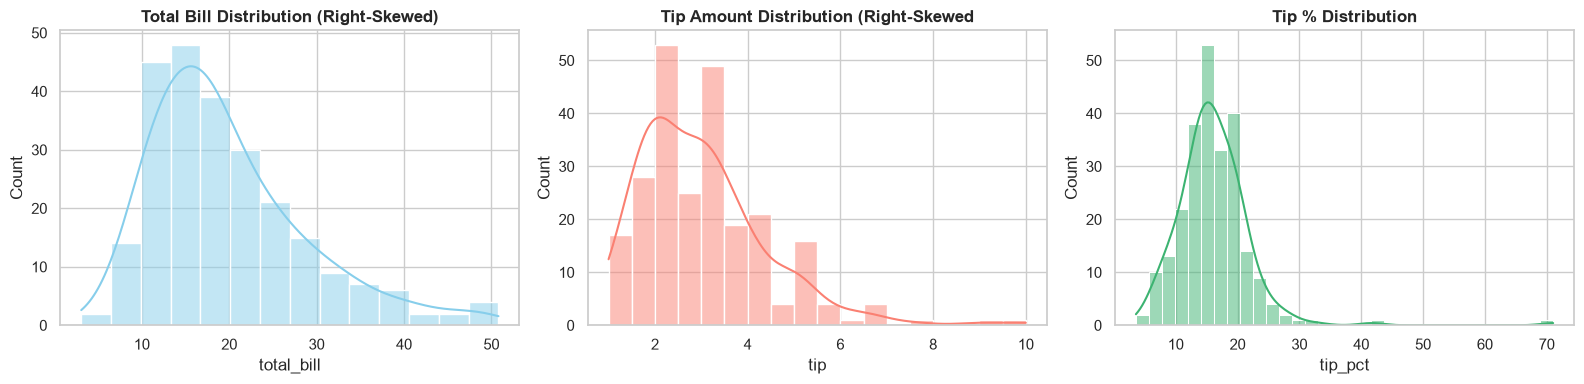

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4)) # 3 plots in 1 row

# 1. Total Bill Distribution
sns.histplot(df_clean['total_bill'], kde=True, ax=axes[0], color='skyblue') # in first plot => [0]
axes[0].set_title('Total Bill Distribution (Right-Skewed)', fontweight='bold')

# 2. Tip Amount Distribution
sns.histplot(df_clean['tip'], kde=True, ax=axes[1], color='salmon') # in second plot => [1]
axes[1].set_title('Tip Amount Distribution (Right-Skewed', fontweight='bold')

# 3. Tip Percentage Distribution
sns.histplot(df_clean['tip_pct'], kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Tip % Distribution', fontweight='bold')

plt.tight_layout() # automatically adjusts subplot parameters to prevent overlapping of titles, labels, and ticks
plt.show()


what is tip percentage here? considering min is 3.56 and max is 71 and mean is 16.08%, what does this 16.08% signifies? is it a bad thing

why use histplot here


### 4. Bivariate Linear Regression EDA (`total_bill` vs. `tip`)
Using `regplot` for linear regression.

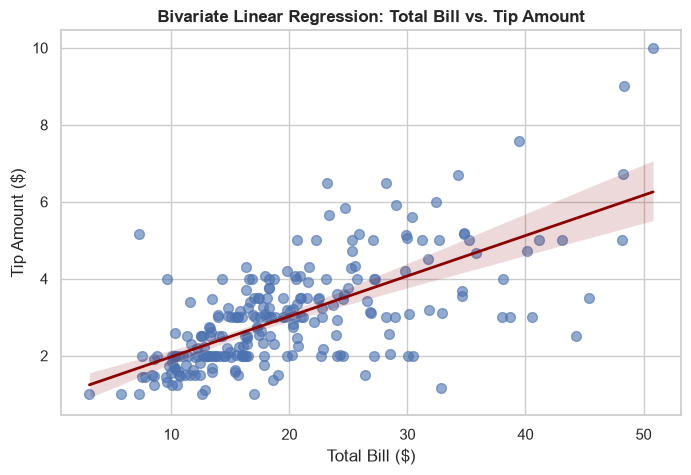

In [10]:
plt.figure(figsize=(8, 5))

# scatter plot with linear regression and 95% confidence interval
sns.regplot(
    data=df_clean,
    x='total_bill',
    y='tip',
    scatter_kws={'alpha':0.6, 's':50}, # what's the meaning of this?
    line_kws={'color':'darkred', 'linewidth': 2} # what's the meaning of this?
)

plt.title('Bivariate Linear Regression: Total Bill vs. Tip Amount', fontweight='bold', fontsize=12)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip Amount ($)')
plt.show()

what's regplot and how to read?

### 5. Sub-Group Trend Analysis (Categorical Interactions)
Using `lmplot` to segment regression trends across categories.

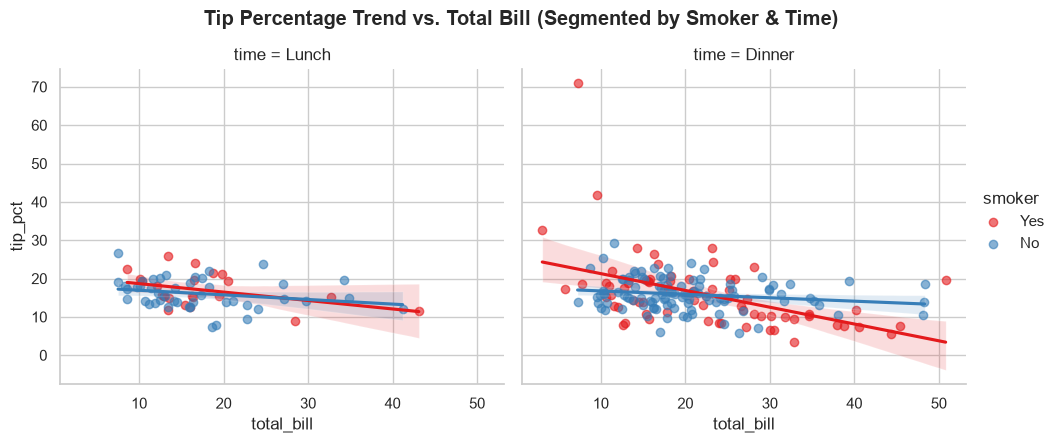

In [12]:
sns.lmplot(
    data=df_clean,
    x='total_bill',
    y='tip_pct',
    hue='smoker',
    col='time', # what's the meaning of this?
    palette='Set1',
    height=4.5, # what's the meaning of this?
    aspect=1.1, # what's the meaning of this?
    scatter_kws={'alpha': 0.6} # what's the meaning of this?
)

plt.subplots_adjust(top=0.85) # what's the meaning of this?
plt.suptitle('Tip Percentage Trend vs. Total Bill (Segmented by Smoker & Time)', fontweight='bold')
plt.show()

what's lmplot and how to read

regplot vs lmplot

when to use these two

importance

what can we get from these plots

### 6. Log Transformation & Correlation Heatmap
To handle right-skewness and stabilize variance in regression relationships, we apply a logarithmic transformation (`np.log1p`) and compute the Pearson correlation matrix.

-- what is Pearon correlation matrix?

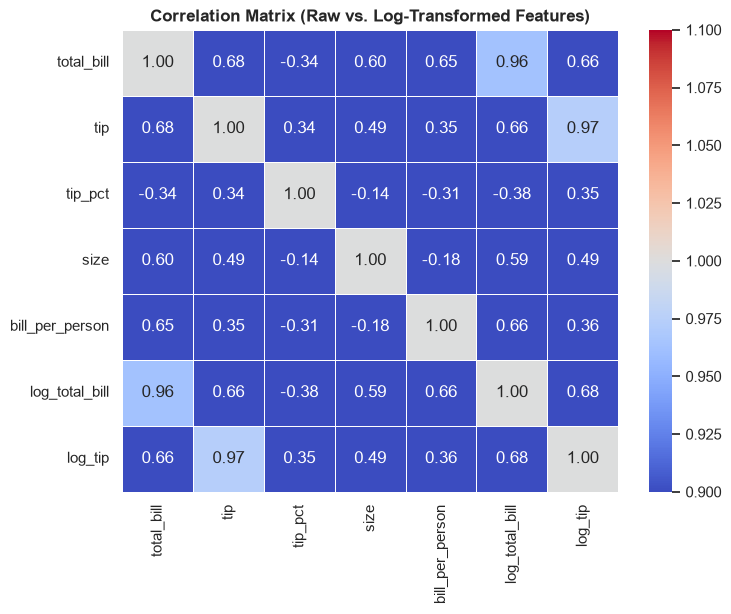

In [13]:
# apply log transformations to skewed variables
df_clean['log_total_bill'] = np.log1p(df_clean['total_bill']) # why use log1p
df_clean['log_tip'] = np.log1p(df_clean['tip'])

# select numeric columns for correlation matrix
numeric_cols = ['total_bill', 'tip', 'tip_pct', 'size', 'bill_per_person', 'log_total_bill', 'log_tip'] # (?) or do df_clean.select_dtypes(include=['float64', 'int64']) 
corr_matrix=df_clean[numeric_cols].corr()

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
           vmin=1, # what's the meaning of this?
           vmax=1, # what's the meaning of this?
           linewidths=0.5)
plt.title('Correlation Matrix (Raw vs. Log-Transformed Features)', fontweight='bold')
plt.show()

## Executive Summary & Key Analytical Findings

### 1. Primary Regression Trend (Total Bill vs. Tip)
* **Positive Correlation:** There is a strong positive linear relationship between `total_bill` and absolute `tip` amount ($r \approx 0.68$). [cite_start]As the bill increases, the dollar amount tipped generally increases[cite: 102].
* **Diminishing Returns (Tip Percentage):** While the total dollar tip increases with larger bills, the **tip percentage (`tip_pct`) exhibits a slight negative slope**. Higher total bills tend to yield lower overall tip percentages compared to smaller bills.

---

### 2. Sub-Group Interactions
* **Smokers vs. Non-Smokers:** Non-smokers display a consistent, steady tipping behavior. Smokers show significantly higher variance (higher volatility in tip percentages, including noticeable high-end outliers).
* **Party Size & Per-Person Cost:** Party size (`size`) correlates moderately with total bill ($r \approx 0.60$), but individual contribution (`bill_per_person`) is a stronger driver of higher percentage tipping.

---

### 3. Skewness & Data Transformations
* Both `total_bill` and `tip` exhibit noticeable right-skewness[cite: 160]. 
* [cite_start]Applying a logarithmic transformation (`log_total_bill` and `log_tip`) linearizes the variance, stabilizing features for linear regression modeling.